# Flat Core verbs — `points`, `polygons`, `choropleth`

The 3-D tier answers the same **Core vocabulary** as every other backend, drawn flat on the ground
plane (`z = 0`). These are distinct from their raised cousins:

| flat (this notebook) | raised (elsewhere) |
|---|---|
| `points()` — markers at `z=0` | `point_cloud()` — a `z` per point (notebook 03) |
| `polygons()` / `choropleth()` — flat fills | `extruded_polygons()` — prisms (notebook 05) |

`polygons` fills every footprint in one colour; `choropleth` is `polygons` that **always** colours by a
`column`. Both carve interior rings (holes). We use the shipped Rhine vectors plus a tiny synthetic set.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from digitalearth.base.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
import geopandas as gpd

## `points()` — flat markers coloured by a column

The Rhine gauges, coloured by observed `discharge`. The markers are enlarged (`size=40`) so 34 sparse gauges read clearly over the basin's extent.

C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\viz3d\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


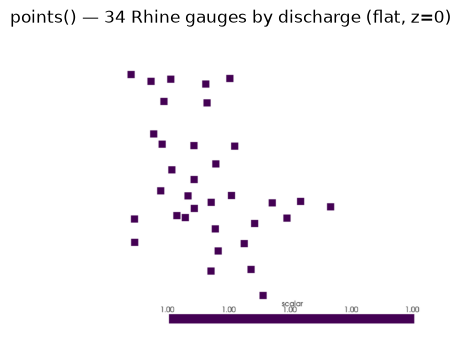

In [2]:
gauges = gpd.read_file(str(DATA / 'rhine_gauges.geojson'))
scene = Scene3D(off_screen=True)
scene.points(gauges, column='discharge', cmap='viridis', size=40.0)
scene.view('top')
show(scene, 'points() — 34 Rhine gauges by discharge (flat, z=0)')
scene.close()

## `polygons()` — flat filled footprints

One flat fill of the Rhine basin outline.

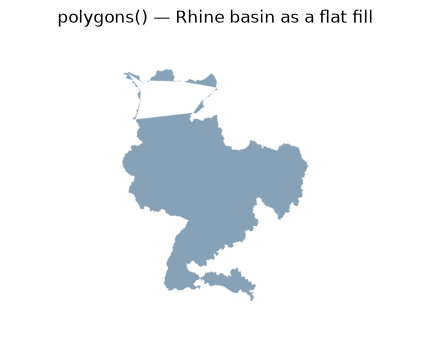

In [3]:
basin = gpd.read_file(str(DATA / 'rhine_basin.geojson'))
scene = Scene3D(off_screen=True)
scene.polygons(basin, color='steelblue', opacity=0.6)
scene.view('top')
show(scene, 'polygons() — Rhine basin as a flat fill')
scene.close()

## `choropleth()` — flat fill coloured by a column

`choropleth` requires a `column` and classifies it (here into quantiles). We build four synthetic zones
with a `population` value so the classes are obvious.

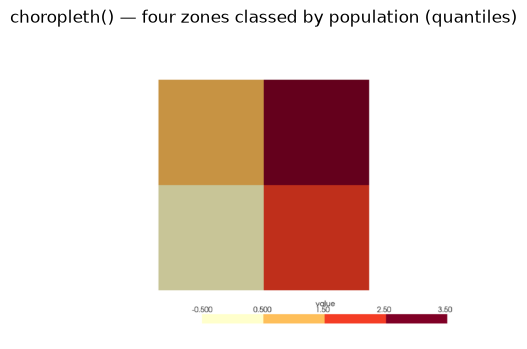

In [4]:
from shapely.geometry import Polygon

zones = gpd.GeoDataFrame(
    {'population': [12.0, 48.0, 25.0, 61.0]},
    geometry=[
        Polygon([(0, 0), (1, 0), (1, 1), (0, 1)]),
        Polygon([(1, 0), (2, 0), (2, 1), (1, 1)]),
        Polygon([(0, 1), (1, 1), (1, 2), (0, 2)]),
        Polygon([(1, 1), (2, 1), (2, 2), (1, 2)]),
    ],
)
scene = Scene3D(off_screen=True)
scene.choropleth(zones, column='population', scheme='quantiles', k=4, cmap='YlOrRd')
scene.view('top')
show(scene, 'choropleth() — four zones classed by population (quantiles)')
scene.close()

**Recap.** `points`/`polygons`/`choropleth` are the *flat* Core verbs (ground plane). Reach for
`point_cloud` (notebook 03) when each point carries a height, and `extruded_polygons` (notebook 05)
when footprints should rise into prisms.